<h1 style="color:#004080; font-size:2em; margin-bottom:0.3em;">
  S3 Read: Analyze a Cloud-Native IVT Zarr for Atmospheric Rivers
</h1>
<h4 style="color:gray; font-weight:normal; line-height:1.5;">
  This notebook shows how to authenticate with HydroShare and stream a cloud-native Zarr (~40&nbsp;GB) of Integrated Vapor Transport (IVT) derived from the CESM2 Large Ensemble (LENS2). The full collection (~1.9&nbsp;PB, NetCDF) is hosted by the NSF Research Data Archive (dataset d651056). In August&nbsp;2024, we extracted a ~40&nbsp;GB IVT subset from the legacy NCAR archive and republished it on HydroShare in Zarr format. Using HydroShare’s S3-compatible endpoint with xarray+dask, we perform time/space subsetting and detect atmospheric rivers (ARs) with the common IVT&nbsp;&ge;&nbsp;250&nbsp;kg/m/s&nbsp; threshold, then assign AR categories based on joint intensity and duration. We also compute an “AR degree” metric, defined as event-integrated IVT (the sum of IVT over an event’s duration; IVT × days), as a simple indicator of event severity.
</h4>




<div style="background-color: #f7f7f7; padding: 10px; border-radius: 5px;">
    <p><strong>Authors:</strong> 
    <ul>
        <li>Irene Garousi-Nejad, <a href="mailto:igarousi@cuahsi.org">igarousi@cuahsi.org</a></li>
        <li>Anthony Castronova, <a href="mailto:acastronova@cuahsi.org">acastronova@cuahsi.org</a></li>
    </ul>
    </p>
    <p><strong>Last Modified:</strong> 8/22/25</p>
    <p><strong>Software Requirements:</strong> This notebook has been tested using Python v3.11.8 using the following library versions:
        <ul>
            <li>dask>=2025.7.0</li>
            <li>xarray>=2024.2.0</li>
            <li>geopandas>=1.1.1</li>
            <li>h5netcdf>=1.6.4</li>
            <li>hvplot>=0.11.3</li>
            <li>requests>=2.32.2</li>
            <li>rioxarray>=0.19.0</li>
            <li>s3fs>=2025.5.1</li>
            <li>numpy>=2.3.1</li>
            <li>cftime>=1.6.4</li>
            <li>folium>=0.20.0</li>
        </ul>
    </p>
    <p><strong>Supporting Files and Dependencies:</strong> 
        <ul>
            <li>ARUtils.py</li>           
        </ul>
    </p>
    <p><strong>References:</strong></p>
    <ul>
        <li>https://psl.noaa.gov/technology/aro/</li>
        <li>https://cw3e.ucsd.edu/heavy-rain-in-the-pacific-northwest/</li>
        <li>https://rda.ucar.edu/datasets/d651056/dataaccess/#</li>
        <li>Ralph FM, Rutz JJ, Cordeira JM, Dettinger M, Anderson M, Reynolds D, Schick LJ, Smallcomb C (2019) A scale to characterize the Strength and impacts of Atmospheric Rivers. Bull Am Meteorol Soc 100(2):269–289. https://doi.org/10.1175/BAMS-D-18-0023.1</li>
        <li>https://www.cesm.ucar.edu/community-projects/lens2</li>
    </ul>
</div>

## 1. Environment Setup: Imports & Dask (Cluster/Client)

In [1]:
import os
import cftime
import dask
import folium
import hvplot.xarray  
from dask.distributed import Client
import s3fs
import numpy as np
import xarray as xr
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
import matplotlib.pyplot as plt
import requests
import importlib.util
from getpass import getpass
def is_installed(package_name):
    return importlib.util.find_spec(package_name) is not None
import ARUtils
print("h5netcdf installed:", is_installed("h5netcdf"))
print("h5py installed:", is_installed("h5py"))


h5netcdf installed: True
h5py installed: True


In [2]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print(client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    # This is configured for a "Large" instance on ciroh.awi.2i2c.cloud
    # client = Client()
    client = Client(n_workers=1, threads_per_worker=2, memory_limit="12GB") 
    print(client.dashboard_link)

dask.config.set({'array.slicing.split_large_chunks': True})


/user/igarousi/proxy/8787/status


## 2. Authenticate to HydroShare & Configure S3FS 

The following cells first obtain S3 credentials from the HydroShare API, initialize `s3fs` for the HydroShare S3 endpoint, and find the exact bucket and key prefix for the resource, then combine them to build `s3_path` for listin/reading the Zarr store.


In [3]:
# sing in
username = "igarousi"
password = getpass('Enter your password: ')
resource_id = "53effa6f532b43a5972daa5336932224"

Enter your password:  ········


In [4]:
# create access key and secret for the authenticated user
response = requests.post(f"https://hydroshare.org/hsapi/user/service/accounts/s3/", auth=(username, password))
response_json = response.json()
access_key = response_json['access_key']
secret_key = response_json['secret_key']

In [5]:
# create a filesystem-like client for S3
s3 = s3fs.S3FileSystem(key=access_key,
                       secret=secret_key,
                       endpoint_url='https://s3.hydroshare.org')

In [9]:
# get the s3_path for the resource_id
response = requests.get(f"https://hydroshare.org/hsapi/resource/s3/{resource_id}/", auth=(username, password))
response_json = response.json()
s3_path = f"{response_json['bucket']}/{response_json['prefix']}"

s3.ls(s3_path)

['igarousi/53effa6f532b43a5972daa5336932224/data/contents/ivt.zarr']

## 3. Open the IVT Zarr 

Open lazily

In [10]:
filename='ivt.zarr'
mapper = s3.get_mapper(f"{s3_path.rstrip('/')}/{filename}")
ds = xr.open_zarr(mapper, consolidated=True)

In [11]:
ds

<xarray.Dataset> Size: 41GB
Dimensions:  (time: 366462, lat: 192, lon: 288)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 3MB 1970-01-01 00:00:00 ... 2101-01-01 00:00:00
Data variables:
    IVT      (time, lat, lon) float16 41GB dask.array<chunksize=(1000, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    case:              b.e21.BSSP370smbb.f09_g17.LE2-1011.001
    host:              mom2
    initial_file:      b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.i.2015-01-01-...
    logname:           sunseon
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    source:            CAM
    time_period_freq:  hour_6
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...

Check the dataset chunk sizes

In [12]:
# print(ds.IVT.chunks)
print(ds.IVT.chunksizes)

Frozen({'time': (1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000,

Check file size. Zarr chunks are compressed on disk. HydroShare shows the compressed total (e.g., 24 GiB). `ds.nbytes` reports the uncompressed size of all arrays in the dataset, i.e., what it would take in RAM if loaded.

In [13]:
print(f'Variable size: {ds.nbytes/1e9:.1f} GB')
print('Number of years in one file:', round(ds.time.shape[0]/4/365)) 

Variable size: 40.5 GB
Number of years in one file: 251


The time coordinate in this dataset is not strictly monotonic increasing, which can break label-based slicing, resampling, and merges. First, check it and then fix the order:

In [14]:
def time_order_report(ds: xr.Dataset, dim: str = "time"):
    idx = ds.indexes.get(dim)
    if idx is None:
        raise KeyError(f"No index found for '{dim}'.")
    print(
        f"{dim}: monotonic↑={idx.is_monotonic_increasing}, "
        f"monotonic↓={idx.is_monotonic_decreasing}, "
        f"unique={idx.is_unique}, "
        f"length={len(idx)}"
    )
    return idx

# Example usage
idx = time_order_report(ds)
idx

time: monotonic↑=False, monotonic↓=False, unique=False, length=366462


CFTimeIndex([1970-01-01 00:00:00, 1970-01-01 06:00:00, 1970-01-01 12:00:00,
             1970-01-01 18:00:00, 1970-01-02 00:00:00, 1970-01-02 06:00:00,
             1970-01-02 12:00:00, 1970-01-02 18:00:00, 1970-01-03 00:00:00,
             1970-01-03 06:00:00,
             ...
             2100-12-29 18:00:00, 2100-12-30 00:00:00, 2100-12-30 06:00:00,
             2100-12-30 12:00:00, 2100-12-30 18:00:00, 2100-12-31 00:00:00,
             2100-12-31 06:00:00, 2100-12-31 12:00:00, 2100-12-31 18:00:00,
             2101-01-01 00:00:00],
            dtype='object', length=366462, calendar='noleap', freq=None)

In [15]:
# If not strictly increasing or not unique, fix it:
ds = ds.sortby("time")

# Re-check
_ = time_order_report(ds)

time: monotonic↑=True, monotonic↓=False, unique=False, length=366462


Also, the time axis is a CFTimeIndex, i.e., it uses `cftime` date types for non-Gregorian calendars (e.g., noleap, 360_day). Many plotting and pandas/xarray functions work best with standard NumPy `datetimes`, so we convert to proleptic_gregorian (and drop cftime) before plotting:

In [16]:
# Convert to proleptic_gregorian and drop cftime (requires modern xarray)
ds = ds.convert_calendar("proleptic_gregorian", use_cftime=False)

# If there are duplicate timestamps, drop them first (optional but helpful)
if ds.get_index("time").has_duplicates:
    ds = ds.sel(time=~ds.get_index("time").duplicated())

*Note*: This conversion will drop timestamps that do not exist in the Gregorian calendar (e.g., Feb 29 in noleap).

## 4. Subset to a Location and Period of Interest

Bodega Bay (38.3332° N, 123.0481° W) sits in California’s North Bay, a region frequently impacted by wintertime atmospheric rivers—major drivers of seasonal precipitation and flooding across the Pacific Northwest and Northern California (see [NOAA PSL’s Atmospheric River Observatory](https://psl.noaa.gov/technology/aro/)). In October 2014, for example, the Bodega Bay observatory documented the southernmost reach of an AR that brought significant rainfall to northwestern California ([CW3E report](https://cw3e.ucsd.edu/heavy-rain-in-the-pacific-northwest/)).

In this notebook, we focus on 1970–2009, a late-20th-century subset of the CESM2 LENS historical simulations (1850–2014).

In [17]:
start_date="1970-01-01"
end_date="2009-12-31"
lat = 38.
lon = -123.125 

In [18]:
m = folium.Map(location=[lat, lon], zoom_start=10)
folium.CircleMarker([lat, lon], radius=6, color="red", fill=True, fill_opacity=0.8,
                    popup=f"Lat {lat:.4f}, Lon {lon:.4f}").add_to(m)
m

In [19]:
ds_point = ds.sel(time=slice(start_date, end_date)).sel(lat=lat, lon=lon+360., method='nearest').IVT
ds_point

<xarray.DataArray 'IVT' (time: 58400)> Size: 117kB
dask.array<getitem, shape=(58400,), dtype=float16, chunksize=(998,), chunktype=numpy.ndarray>
Coordinates:
    lat      float64 8B 38.17
    lon      float64 8B 237.5
  * time     (time) datetime64[ns] 467kB 1970-01-01 ... 2009-12-31T18:00:00
Attributes:
    long_name:  Total (vertically integrated) vapor transport
    units:      kg/m/s

Load data

In [20]:
%%time
ds_point = ds_point.load() 

CPU times: user 2.66 s, sys: 193 ms, total: 2.85 s
Wall time: 35.8 s


In [21]:
p = (ds_point.hvplot(label='IVT', color='black', line_dash='dashed', line_width=1)
).opts(
    width=900, height=400, show_grid=True, tools=['hover']
)

p  

:Curve   [time]   (Total (vertically integrated) vapor transport)

Select a set of grid cells that cover Bodega Bay, CA (38.3332° N, 123.0481° W).

In [22]:
# the nearest index for the lat/lon provided above
ilon = list(ds.lon.values).index(ds.sel(lon=lon+360., method='nearest').lon)
ilat = list(ds.lat.values).index(ds.sel(lat=lat, method='nearest').lat)

cell_buffer = 10
# subset these data to include cells above and below this lat/lon
ds_box = ds.sel(time=slice(start_date, end_date)).isel(lat=range(ilat-cell_buffer, ilat+cell_buffer),
                  lon=range(ilon-cell_buffer, ilon+cell_buffer)).IVT

ds_box = ds_box.to_dataset()

In [23]:
%%time
ds_box = ds_box.load()

CPU times: user 2.32 s, sys: 223 ms, total: 2.54 s
Wall time: 31 s


Plot the IVT data for these cells at time=0 to visualize our domain.

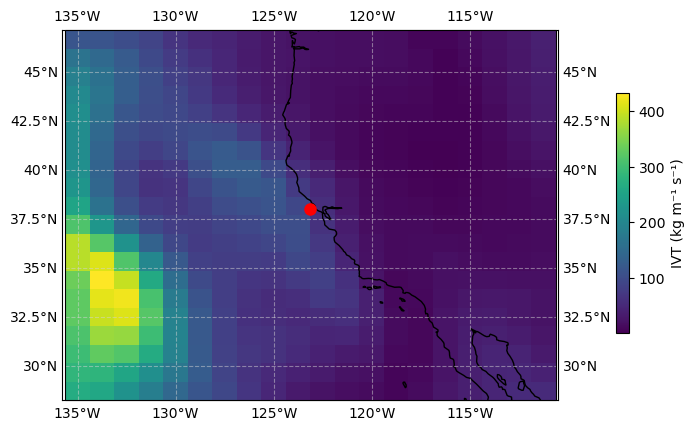

In [24]:
fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
ax = plt.axes(projection=ccrs.PlateCarree())

#add coastlines
ax.add_feature(cfeature.COASTLINE)

#add lat lon grids
gl = ax.gridlines(draw_labels=True, color='lightgrey', alpha=0.5, linestyle='--')
gl.xlabels_bottom = False
gl.ylabels_right = False

plot = ds_box.isel(time=0).IVT.plot(label='',
                         add_labels=False,
                         add_colorbar=False,    
                         xticks=None,
                         yticks=None)

# add custom colorbar inside the figure
cbar_ax = fig.add_axes([0.99, 0.25, 0.02, 0.5])  # [left, bottom, width, height] in figure coords
cbar = plt.colorbar(plot, cax=cbar_ax)
cbar.set_label('IVT (kg m⁻¹ s⁻¹)')

ax.plot(lon+360., lat,
        marker='o', color='red', markersize=8,
        transform=ccrs.PlateCarree())

plt.show()

## 5. Identify Atmospheric River Events

To identify atmospheric rivers, we first flag periods where IVT ≥ 250 kg/m/s, a common screening threshold for AR conditions (Ralph et al., 2019). We then classify AR strength into Categories 1–5 using the Ralph et al. (2019) scale, which combines peak IVT and event duration. Lower categories indicate weaker ARs, while higher categories indicate extreme/exceptional events. This workflow is implemented in our Python utility module `ARUtils.py`.

In [33]:
ds_box

<xarray.Dataset> Size: 795MB
Dimensions:      (lat: 20, lon: 20, time: 58400)
Coordinates:
  * lat          (lat) float64 160B 28.74 29.69 30.63 ... 44.76 45.71 46.65
  * lon          (lon) float64 160B 225.0 226.2 227.5 ... 246.2 247.5 248.8
  * time         (time) datetime64[ns] 467kB 1970-01-01 ... 2009-12-31T18:00:00
Data variables:
    IVT          (time, lat, lon) float16 47MB 266.2 257.5 221.4 ... 22.31 23.05
    AR_INDEX     (lat, lon, time) float64 187MB 1.0 0.0 2.0 2.0 ... 0.0 0.0 0.0
    AR_DURATION  (lat, lon, time) int64 187MB 1 0 12 12 12 12 12 ... 0 0 0 0 0 0
    AR_CATEGORY  (lat, lon, time) float64 187MB 0.0 0.0 4.0 4.0 ... 0.0 0.0 0.0
    AR_DEGREE    (lat, lon, time) float64 187MB 5.751e+06 0.0 ... 0.0 0.0

In [26]:
ds_box.chunks

Frozen({})

In [27]:
# # Ensure time is a single chunk (so events aren’t broken across chunks)
# ds_box = ds_box.chunk({"time": -1})
# ds_box.chunks

Assign an index to each group of timesteps that meet AR conditions

In [28]:
ds_box['AR_INDEX'] = xr.apply_ufunc(
    ARUtils.identify_ar_events,  
    ds_box.IVT,  
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True},
)

Compute the duration for each AR event

In [29]:
ds_box['AR_DURATION'] = xr.apply_ufunc(
    ARUtils.compute_ar_durations,  
    ds_box.AR_INDEX,  
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True},
)

Compute the category (1-5) for each AR event

In [30]:
ds_box['AR_CATEGORY'] = xr.apply_ufunc(
    ARUtils.compute_ar_category,  
    ds_box.AR_INDEX,
    ds_box.AR_DURATION,
    ds_box.IVT,
    input_core_dims=[["time"],["time"],["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True},
)

Compute the probability of each AR event occurring

In [31]:
res = xr.apply_ufunc(
    ARUtils.compute_ar_probability,
    ds_box.AR_INDEX,
    ds_box.AR_CATEGORY,
    input_core_dims=[["time"],["time"]],
    output_core_dims=[['category']],
    # output_sizes={'category': 5},
    output_dtypes=[float],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True,
                        'output_sizes': {'category': 5}},
)

# Add the category dimension (from 1 to 5)
res = res.assign_coords(category=np.arange(1, 6))

# add the newly computed probabilty back to the original dataset
ds = ds.assign(AR_PROBABILITY=res)

Compute the magnitude of each AR event.

In [32]:
ds_box['AR_DEGREE'] = xr.apply_ufunc(
    ARUtils.compute_ar_degree,
    ds_box.IVT,
    ds_box.AR_DURATION,
    ds_box.AR_INDEX,
    input_core_dims=[["time"],["time"],["time"]],
    output_core_dims=[['time']],
    output_dtypes=[float],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True},
)

## 6. Plot Computed AR Category

Mean Atmospheric Rivers category through the record of data. Let's first build contour plots of mean AR_CATEGORY for each decade in our dataset.

In [34]:
year = ds_box["time"].dt.year
decade = np.floor(year / 10) * 10
ds_box = ds_box.assign_coords({'decade':decade})

In [35]:
ds_decade = ds_box.where(ds_box.AR_CATEGORY > 0) \
            .AR_CATEGORY \
            .groupby('decade') \
            .mean(dim='time').compute()

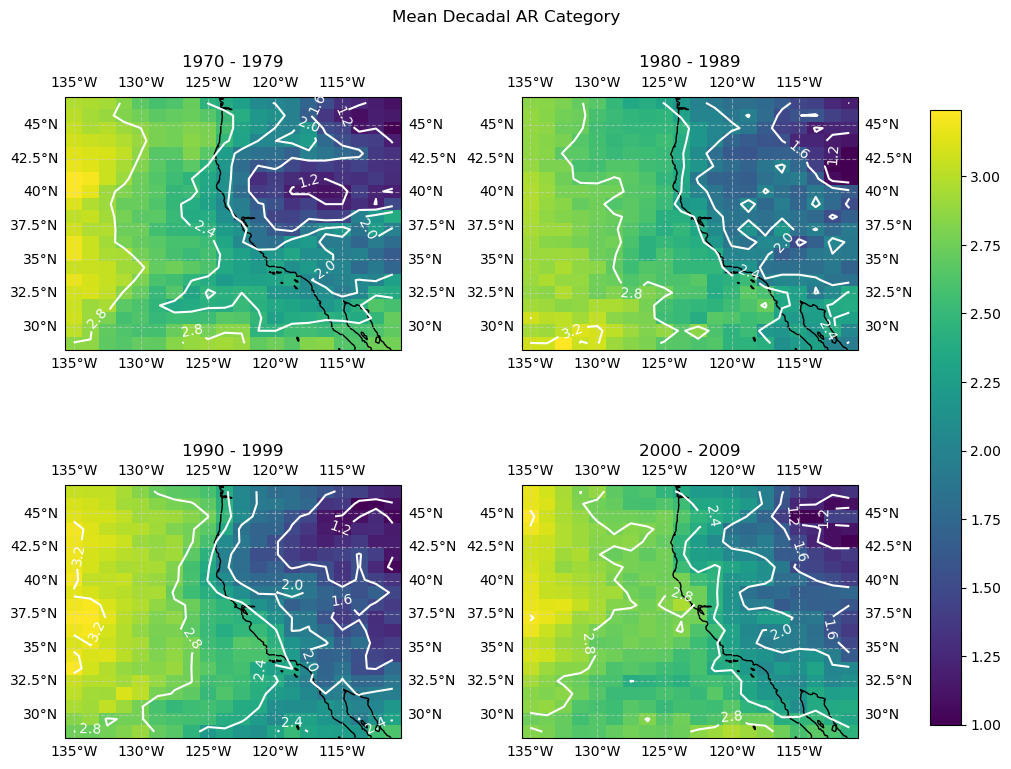

In [36]:
fig, ax = plt.subplots(nrows=2, ncols=2,
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       figsize=(10,8),
                       layout='constrained')

axes = ax.flatten()
for i in range(0, len(ds_decade.decade)):
    axes[i].coastlines();
    axes[i].gridlines(draw_labels=True, color='lightgrey', alpha=0.5, linestyle='--');
    
    # created grid and contour plots.
    d_plot = ds_decade.isel(decade=i).plot(label='',
                   add_labels=False,
                   add_colorbar=False,                   
                   ax=axes[i])
    
    c_plot = ds_decade.isel(decade=i).plot.contour(add_labels=True,
                                                   add_colorbar=False,
                                                   colors='white',
                                                   ax=axes[i])
    axes[i].clabel(c_plot)


    st = int(ds_decade.decade[i].item())
    et = st + 9
    axes[i].set_title(f'{st} - {et}')

fig.colorbar(d_plot, ax=ax[:, 1], shrink=0.8);
fig.suptitle('Mean Decadal AR Category');

Build contour plots of mean AR_DEGREE for each decade in our dataset.

In [37]:
ds_decade = ds_box.where(ds_box.AR_CATEGORY > 0) \
            .AR_DEGREE \
            .groupby('decade') \
            .mean(dim='time').compute()

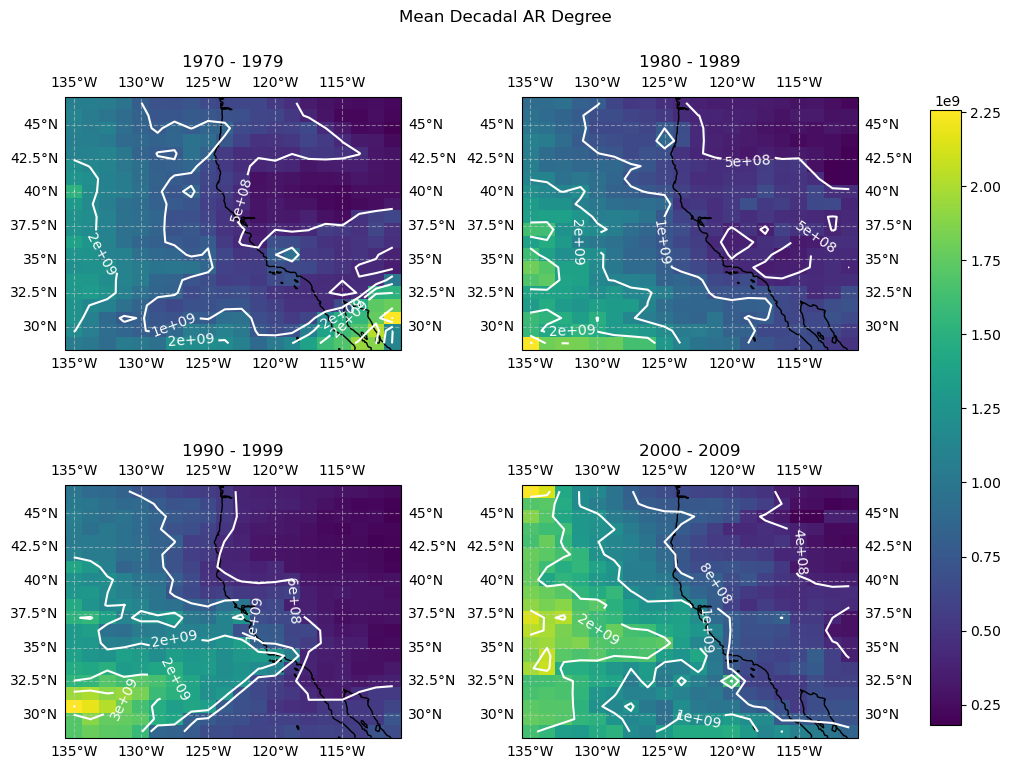

In [38]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots(nrows=2, ncols=2,
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       figsize=(10,8),
                       layout='constrained')

axes = ax.flatten()
for i in range(0, len(ds_decade.decade)):
    axes[i].coastlines();
    axes[i].gridlines(draw_labels=True, color='lightgrey', alpha=0.5, linestyle='--');
    
    # created grid and contour plots.
    d_plot = ds_decade.isel(decade=i).plot(label='',
                   add_labels=False,
                   add_colorbar=False,                   
                   ax=axes[i])
    
    c_plot = ds_decade.isel(decade=i).plot.contour(add_labels=True,
                                                   add_colorbar=False,
                                                   colors='white',
                                                   ax=axes[i])
    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    fmt.create_dummy_axis()    
    
    def fmt_func(value):
        return f'{value:.0e}'
        
        
    axes[i].clabel(c_plot, inline=True, fontsize=10, fmt=fmt_func)


    st = int(ds_decade.decade[i].item())
    et = st + 9
    axes[i].set_title(f'{st} - {et}')

fig.colorbar(d_plot, ax=ax[:, 1], shrink=0.8);
fig.suptitle('Mean Decadal AR Degree');